![NVIDIA Logo](images/nvidia.png)

# Deserialize and Serialize Stages

In this notebook you'll learn how to use `DeserializeStage` and `SerializeStage` to convert between `MessageMeta` and `ControlMessage` messages in your pipelines.

---

## Objectives

By the time you complete this notebook you will be able to:

- Use `DeserializeStage` to convert `MessageMeta` messages to `ControlMessage` messages.
- Use `DeserializeStage` in conjuction with a pipeline's `Config` to specify a pipeline's batch size.
- Use `SerializeStage` to convert `ControlMessage` messages to `MessageMeta` messages.

---

## Imports

In [1]:
import logging

from IPython.display import Image

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage
from morpheus.stages.preprocess.deserialize_stage import DeserializeStage
from morpheus.stages.postprocess.serialize_stage import SerializeStage

from morpheus.utils.logger import configure_logging, reset_logging

---

## The Deserialize Stage

`morpheus.stages.preprocess.deserialize_stage.DeserializeStage` transforms `MessageMeta` objects into `ControlMessage` objects and can group messages into batches of a specified size, which is useful for optimizing processing in later stages.

---

## The Serialize Stage

`morpheus.stages.preprocess.serialize_stage.SerializeStage` transforms `ControlMessage` objects back into `MessageMeta` objects.

---

## A Pipeline With a Serialization Cycle

Let's take a look at a no-op passthorugh cycle utilizing `DeserializeStage` and a `SerializeStage`.

In [2]:
input_file = 'data/simple_user_log.jsonlines'
config = Config()
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

pipeline.add_stage(DeserializeStage(config))
pipeline.add_stage(SerializeStage(config))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [3]:
pipeline.build()

In [4]:
viz_file = './pipeline_visualizations/deserialize-serialize.png'
pipeline.visualize(viz_file)

Looking at our pipeline visualization, we can see that `deserialize` emits a `ControlMessage`, which `serialize` expects. `serialize`, as you can see, emits a `MessageMeta`.

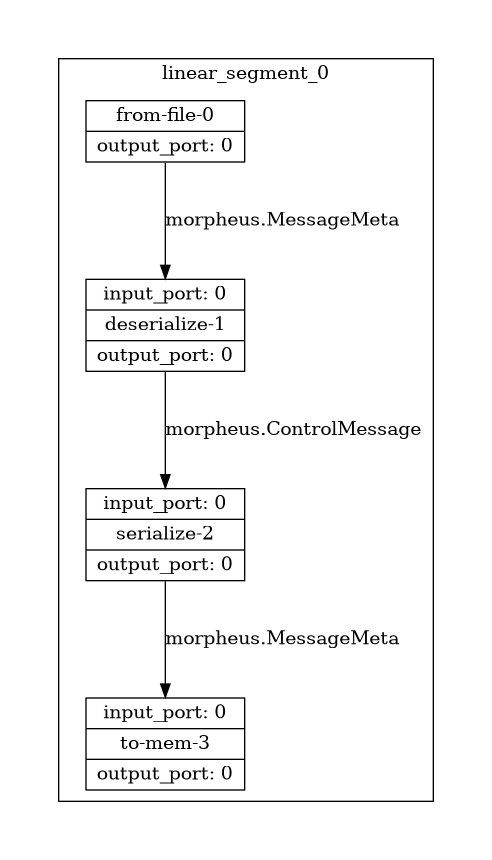

In [5]:
Image(filename=viz_file)

In [6]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <deserialize-1; DeserializeStage(ensure_sliceable_index=True, task_type=None, task_payload=None)>
  └─ morpheus.MessageMeta -> morpheus.ControlMessage
Added stage: <serialize-2; SerializeStage(include=None, exclude=None, fixed_columns=True)>
  └─ morpheus.ControlMessage -> morpheus.MessageMeta
Added stage: <to-mem-3; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====
====Pipeline Pre-build====
====Pre-Building Segment: linear_segment_0====
====Pre-Building Segment Complete!====
====Pipeline Pre-build Complete!====
====Registering Pipeline====
====Building Pipeline====
====Bui

In [7]:
await pipeline.run_async()

Looking at the logging above, you can also see the various stages' input and output message types. Notice the conversions between `MessageMeta` and `ControlMessage` via the `DeserializeStage` and `SerializeStage` stages.

We've simplified the output below to make more clear the message type conversions.

```
FileSourceStage
  └─> morpheus.MessageMeta
  
DeserializeStage
  └─ morpheus.MessageMeta -> morpheus.ControlMessage
  
SerializeStage
  └─ morpheus.ControlMessage -> morpheus.MessageMeta
  
InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
```

---

## Setting Pipeline Batch Size

`DeserializeStage` also allows us to set the pipeline batch size, which by default is set to 256.

As an example, here we set `pipeline_batch_size` to `2`.

In [8]:
config = Config()
config.pipeline_batch_size = 2

Let's create a run a new pipeline using the `config` object we just created.

In [9]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))

pipeline.add_stage(DeserializeStage(config))
pipeline.add_stage(SerializeStage(config))

in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

pipeline.build()

await pipeline.run_async()

By inspecting `in_mem_sink`, we can see that the pipeline worked on batches of 2 data entries from our original source file.

In [10]:
messages = in_mem_sink.get_messages()

In [11]:
# Our dataset has 10 entries, so there are 5 messages of 2 rows each.
len(messages)

5

In [12]:
message = messages[0]

In [13]:
message.get_data()

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
